# Project 4 - Interpreting Data

**Data Preperation**

***Importing and Merging***


In [15]:
#importing all different libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from PIL import Image
from IPython.display import display

In [16]:
#creating data sets
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
indi_nri = all_tracts[all_tracts["STATE"] == "Indiana"]
indi_svi = pd.read_csv("indiana.csv")

kan_nri = all_tracts[all_tracts["STATE"] == "Kansas"]
kan_svi = pd.read_csv("Kansas.csv")


In [17]:
kan_nri.head(1)

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
29866,30746,T20001952600,Kansas,KS,20,Allen,County,1,20001,952600,...,90.67641,Relatively High,0.000013,4.104483e-07,9.270264e-07,83.120337,21079.537153,92.02307,Relatively High,December 2025


In [20]:
#merging data sets
kan_nri['STCNTY'] = kan_nri['STCOFIPS']
indi_nri['STCNTY'] = indi_nri['STCOFIPS']

kan_data = pd.merge(kan_nri, kan_svi, on = 'STCNTY')
indi_data = pd.merge(indi_nri, indi_svi, on = 'STCNTY')


/var/folders/vn/p1pkz2td3411n1620h0kydmh0000gn/T/ipykernel_38647/2735123907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kan_nri['STCNTY'] = kan_nri['STCOFIPS']
/var/folders/vn/p1pkz2td3411n1620h0kydmh0000gn/T/ipykernel_38647/2735123907.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indi_nri['STCNTY'] = indi_nri['STCOFIPS']


KeyError: 'STCNTY'

In [21]:
kan_nri.head(1)

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,STCNTY
29866,30746,T20001952600,Kansas,KS,20,Allen,County,1,20001,952600,...,Relatively High,0.000013,4.104483e-07,9.270264e-07,83.120337,21079.537153,92.02307,Relatively High,December 2025,20001


**Checking and Handling Missing Data**

In [22]:
#checking for missing values
kan_nri = pd.read_csv("Kansas.csv", low_memory = True)
kan_nri = pd.DataFrame(kan_nri)

indi_nri = pd.read_csv("Indiana.csv", low_memory = True)
indi_nri = pd.DataFrame(indi_nri)

print(kan_nri.isna())

        ST  STATE  ST_ABBR  STCNTY  COUNTY   FIPS  LOCATION  AREA_SQMI  \
0    False  False    False   False   False  False     False      False   
1    False  False    False   False   False  False     False      False   
2    False  False    False   False   False  False     False      False   
3    False  False    False   False   False  False     False      False   
4    False  False    False   False   False  False     False      False   
..     ...    ...      ...     ...     ...    ...       ...        ...   
824  False  False    False   False   False  False     False      False   
825  False  False    False   False   False  False     False      False   
826  False  False    False   False   False  False     False      False   
827  False  False    False   False   False  False     False      False   
828  False  False    False   False   False  False     False      False   

     E_TOTPOP  M_TOTPOP  ...  EP_ASIAN  MP_ASIAN  EP_AIAN  MP_AIAN  EP_NHPI  \
0       False     False  ...    

In [23]:
#dealing with missing values with imputation using the mean
indi_nri_fill_min = indi_nri.fillna(indi_nri.mean(numeric_only=True))
kan_nri_fill_min = kan_nri.fillna(kan_nri.mean(numeric_only=True))

## Removing and Replacing N/As

#### Removing N/As

In [32]:
kan_nri_dropped = kan_nri.dropna()
indi_nri_dropped = indi_nri.dropna()

kan_nri_dropped_columns = kan_nri.dropna(axis = 1)
print(kan_nri_dropped_columns)

     ST   STATE ST_ABBR  STCNTY            COUNTY         FIPS  \
0    20  Kansas      KS   20001      Allen County  20001952600   
1    20  Kansas      KS   20001      Allen County  20001952700   
2    20  Kansas      KS   20001      Allen County  20001952800   
3    20  Kansas      KS   20001      Allen County  20001952900   
4    20  Kansas      KS   20001      Allen County  20001953000   
..   ..     ...     ...     ...               ...          ...   
824  20  Kansas      KS   20209  Wyandotte County  20209980000   
825  20  Kansas      KS   20209  Wyandotte County  20209980500   
826  20  Kansas      KS   20209  Wyandotte County  20209980900   
827  20  Kansas      KS   20209  Wyandotte County  20209981200   
828  20  Kansas      KS   20209  Wyandotte County  20209981500   

                                        LOCATION   AREA_SQMI  E_TOTPOP  \
0        Census Tract 9526; Allen County; Kansas  270.891034      1946   
1        Census Tract 9527; Allen County; Kansas   92.68016

#### Replacing N/As - Imputation

In [34]:
kan_nri_filled_0 = kan_nri.fillna(0)
indi_nri_filled_0 = indi_nri.fillna(0)


print(kan_nri_filled_0)

     ST   STATE ST_ABBR  STCNTY            COUNTY         FIPS  \
0    20  Kansas      KS   20001      Allen County  20001952600   
1    20  Kansas      KS   20001      Allen County  20001952700   
2    20  Kansas      KS   20001      Allen County  20001952800   
3    20  Kansas      KS   20001      Allen County  20001952900   
4    20  Kansas      KS   20001      Allen County  20001953000   
..   ..     ...     ...     ...               ...          ...   
824  20  Kansas      KS   20209  Wyandotte County  20209980000   
825  20  Kansas      KS   20209  Wyandotte County  20209980500   
826  20  Kansas      KS   20209  Wyandotte County  20209980900   
827  20  Kansas      KS   20209  Wyandotte County  20209981200   
828  20  Kansas      KS   20209  Wyandotte County  20209981500   

                                        LOCATION   AREA_SQMI  E_TOTPOP  \
0        Census Tract 9526; Allen County; Kansas  270.891034      1946   
1        Census Tract 9527; Allen County; Kansas   92.68016

## Mapping

#### Read the Census Tracts data

In [35]:
tracts = gpd.read_file('NRI_shapefile_CensusTracts.shp')
tracts.head()
tracts.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

#### Clean Data

In [36]:
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True)
tracts_clean = tracts_clean.to_crs(epsg = 4326)
tracts_clean = tracts_clean.replace(-9999, np.nan)

tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg = 4326)

tracts_clean = tracts_clean.to_crs("ESRI:102003")
tracts_clean.head()

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."


## Cloropleth Maps

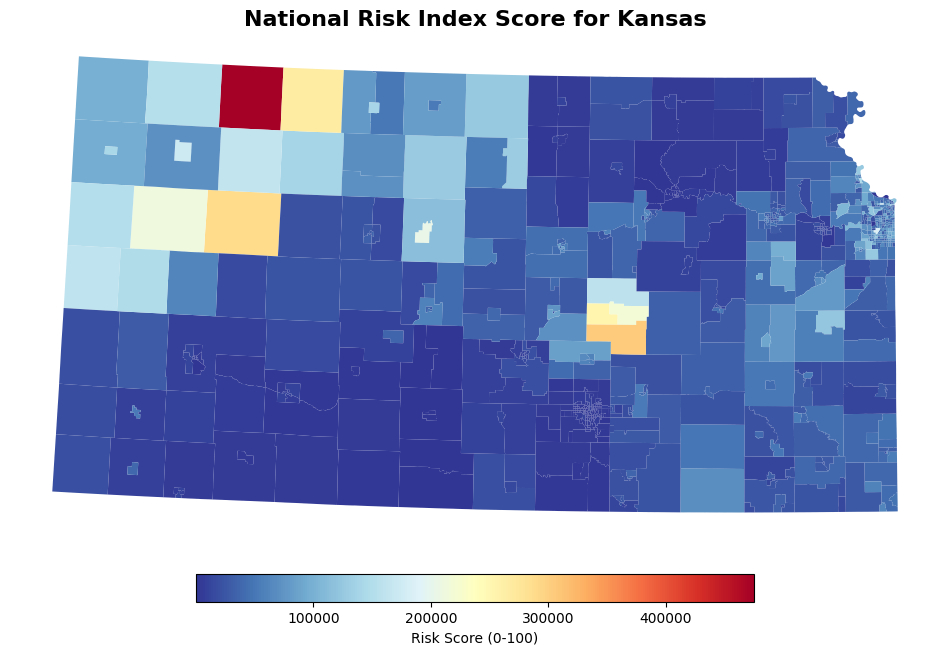

In [37]:
state_name = "Kansas"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize = (12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax = ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6, "pad":0.05},
    missing_kwds = {"color": "lightgrey", "label":"No Data"},
)
ax.set_title("National Risk Index Score for Kansas", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

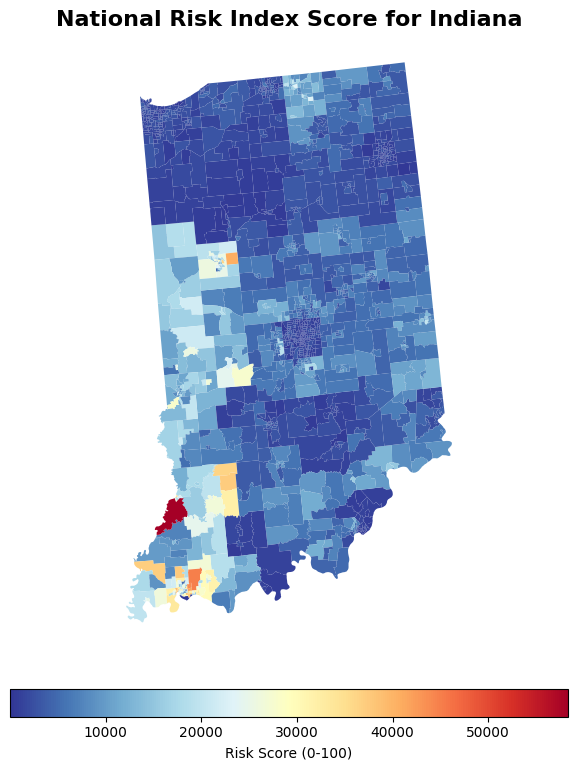

In [38]:
state_name = "Indiana"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize = (12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax = ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6, "pad":0.05},
    missing_kwds = {"color": "lightgrey", "label":"No Data"},
)
ax.set_title("National Risk Index Score for Indiana", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

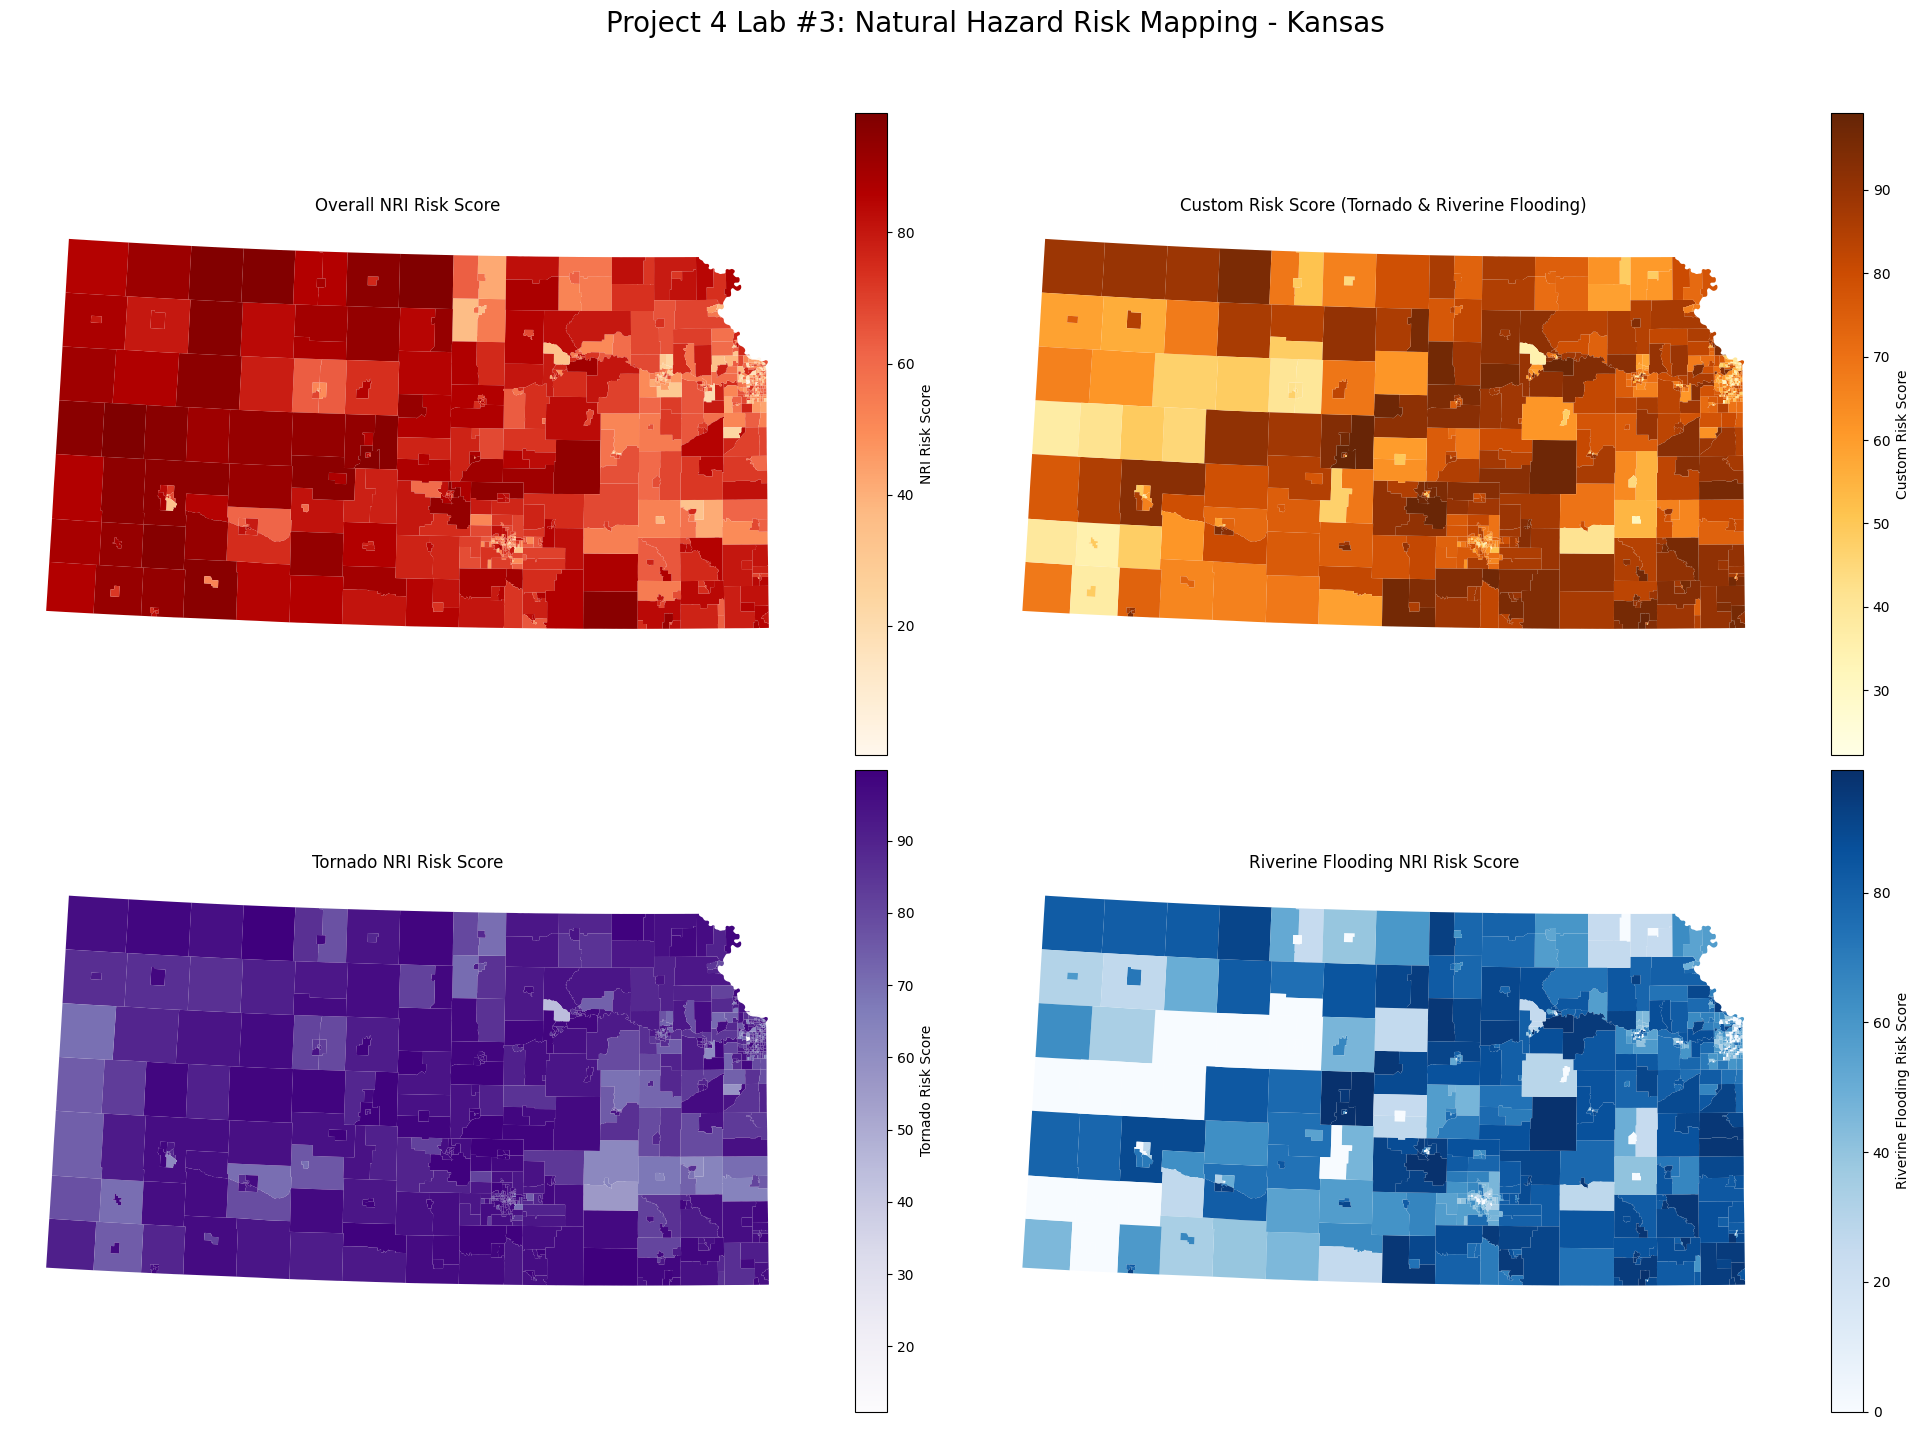

In [40]:
state_data = tracts_clean[tracts_clean['STATE'] == 'Kansas'].copy()

# Risk based on Tornado and Riverine Flooding scores.
hazards = ['TRND_RISKS', 'RFLD_RISKS'] # Tornado and Riverine Flooding scores
state_data['Custom_Risk'] = state_data[hazards].mean(axis=1)

# Create the 4 maps
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Project 4 Lab #3: Natural Hazard Risk Mapping - Kansas', fontsize=20)

# NRI General Risk Score
state_data.plot(column='RISK_SCORE', cmap='OrRd', legend=True, ax=axes[0, 0],
                legend_kwds={'label': "NRI Risk Score"})
axes[0, 0].set_title('Overall NRI Risk Score')

# Custom Composite Risk Score (Tornado + Flooding)
state_data.plot(column='Custom_Risk', cmap='YlOrBr', legend=True, ax=axes[0, 1],
                legend_kwds={'label': "Custom Risk Score"})
axes[0, 1].set_title('Custom Risk Score (Tornado & Riverine Flooding)')

# Tornado Risk
state_data.plot(column='TRND_RISKS', cmap='Purples', legend=True, ax=axes[1, 0],
                legend_kwds={'label': "Tornado Risk Score"})
axes[1, 0].set_title('Tornado NRI Risk Score')

# Riverine Flooding Risk
state_data.plot(column='RFLD_RISKS', cmap='Blues', legend=True, ax=axes[1, 1],
                legend_kwds={'label': "Riverine Flooding Risk Score"})
axes[1, 1].set_title('Riverine Flooding NRI Risk Score')

# Clean up axes
for ax in axes.flat:
    ax.set_axis_off()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



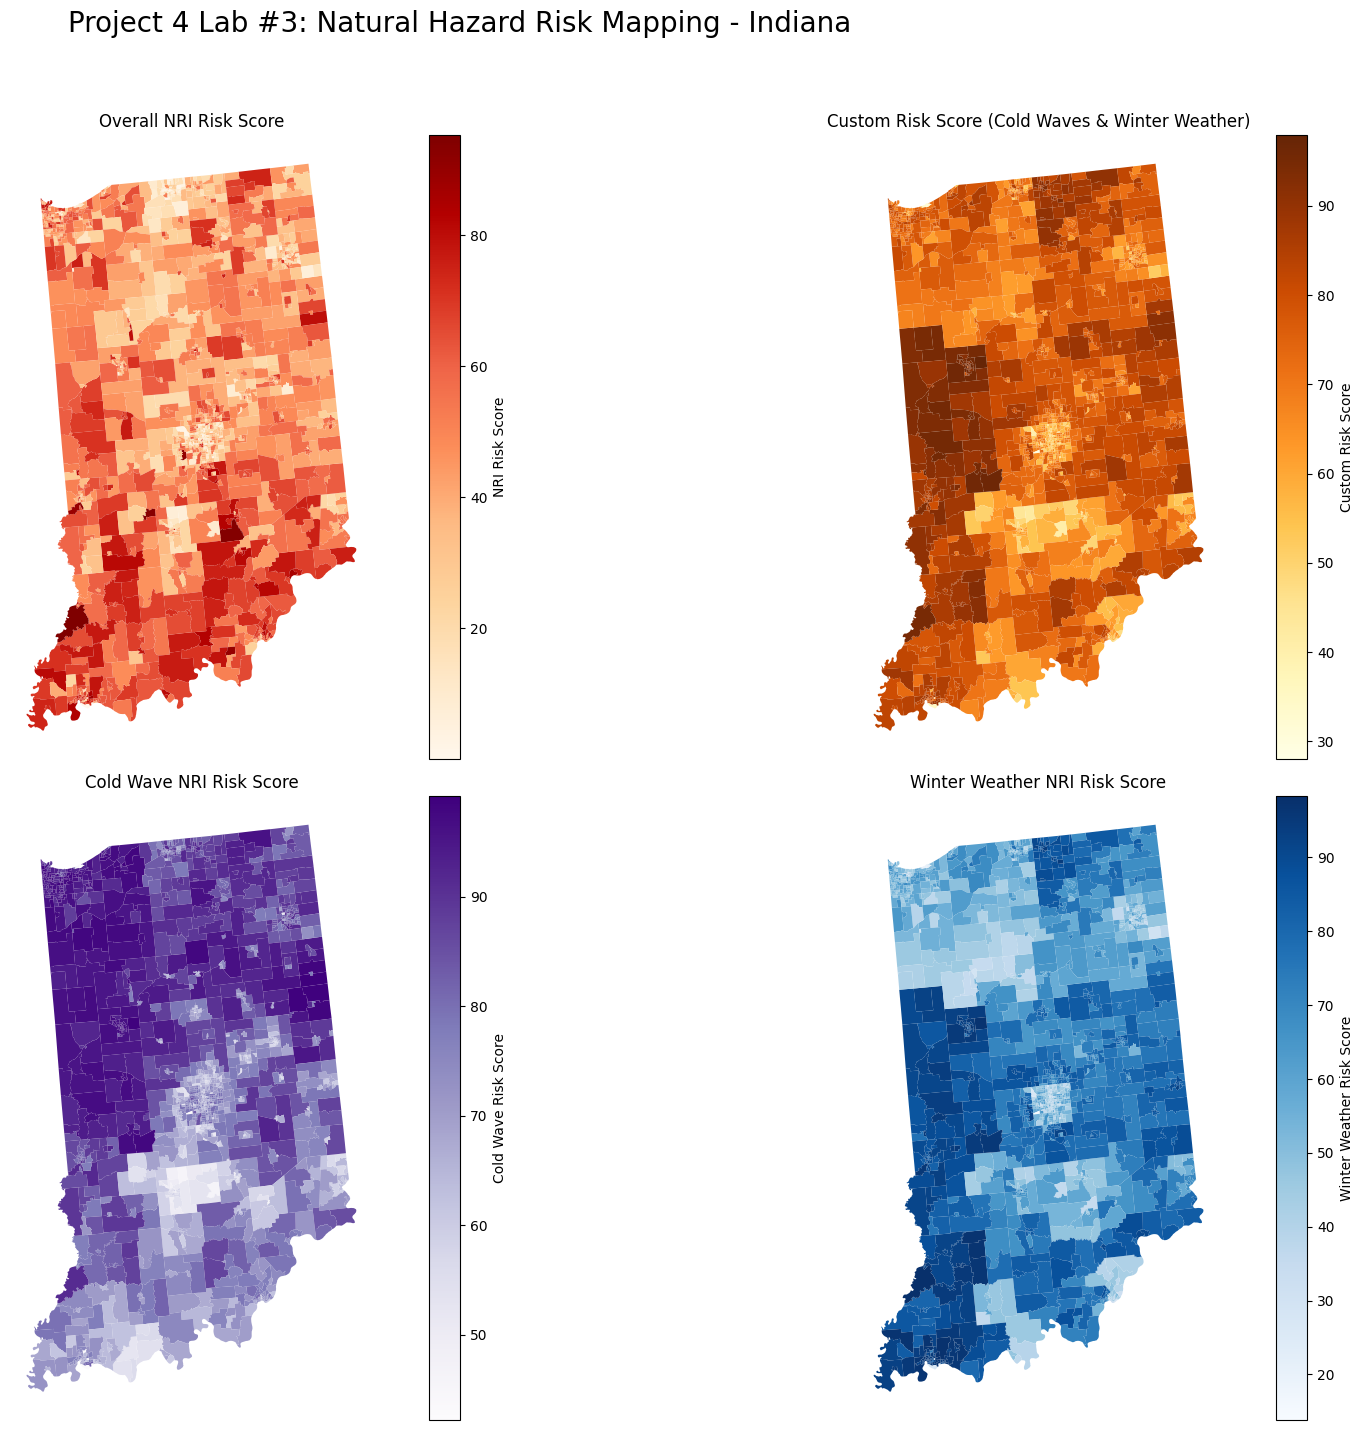

In [41]:
state_data = tracts_clean[tracts_clean['STATE'] == 'Indiana'].copy()

# Risk based on Cold Wave and Winter Weather scores.
hazards = ['CWAV_RISKS', 'WNTW_RISKS'] # Cold Wave and Winter Weather scores
state_data['Custom_Risk'] = state_data[hazards].mean(axis=1)

# Create the 4 maps
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Project 4 Lab #3: Natural Hazard Risk Mapping - Indiana', fontsize=20)

# NRI General Risk Score
state_data.plot(column='RISK_SCORE', cmap='OrRd', legend=True, ax=axes[0, 0],
                legend_kwds={'label': "NRI Risk Score"})
axes[0, 0].set_title('Overall NRI Risk Score')

# Custom Composite Risk Score (Cold Wave + Winter Weather)
state_data.plot(column='Custom_Risk', cmap='YlOrBr', legend=True, ax=axes[0, 1],
                legend_kwds={'label': "Custom Risk Score"})
axes[0, 1].set_title('Custom Risk Score (Cold Waves & Winter Weather)')

# Cold Wave Risk
state_data.plot(column='CWAV_RISKS', cmap='Purples', legend=True, ax=axes[1, 0],
                legend_kwds={'label': "Cold Wave Risk Score"})
axes[1, 0].set_title('Cold Wave NRI Risk Score')

# Winter Weather Risk
state_data.plot(column='WNTW_RISKS', cmap='Blues', legend=True, ax=axes[1, 1],
                legend_kwds={'label': "Winter Weather Risk Score"})
axes[1, 1].set_title('Winter Weather NRI Risk Score')

# Clean up axes
for ax in axes.flat:
    ax.set_axis_off()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
